In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import brentq
from scipy.optimize import minimize,NonlinearConstraint
from scipy.stats import norm

from scipy.stats import kstest, expon
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

from tick.hawkes import SimuHawkesExpKernels

In [ ]:
#Let's first try to modelise a Discrete Hawkes process 

def DHP(kernel,gamma,theta,law,n,mu):
    if kernel=="Erlang":
        alpha=np.array([gamma*np.exp(-k*theta)*k for k in range(0,n)])
    if kernel=="Exponential":
        alpha=np.array([gamma*np.exp(-k*theta) for k in range(0,n)])
    
    alpha[0]=mu
    X_values=np.zeros(n)
    Sn=np.zeros(n)


    if law=="Bernouilli":
        X_values[0]=np.random.binomial(1,alpha[0])
        Sn[0]=X_values[0]
        for k in range(1,n):
            X_values[k]=np.random.binomial(1,alpha[0]+np.sum(alpha[k-1:0:-1]*X_values[1:k]))
            Sn[k]=Sn[k-1]+X_values[k]
    if law=="Poisson":
        X_values[0]=np.random.poisson(alpha[0])
        Sn[0]=X_values[0]
        for k in range(1,n):
            X_values[k]=np.random.poisson(alpha[0]+np.sum(alpha[k-1:0:-1]*X_values[1:k]))
            Sn[k]=Sn[k-1]+X_values[k]


    mu=mu/(1+alpha[0]-np.sum(alpha)) #on veut pas d'mu or np.sum(alpha) l'inclut

    if law=="Bernouilli":
        sigma_asy=mu*(1-mu)/((1+alpha[0]-np.sum(alpha))**2) #same
    if law=="Poisson":
        sigma_asy=mu/((1+alpha[0]-np.sum(alpha))**2) #same

    Sn_div_n=[Sn[k]/(k+1) for k in range(0,n)]
    sigma_div=np.array([sigma_asy/np.sqrt(k+1) for k in range(0,n)])

    upper=mu + 1.96*sigma_div
    lower=mu - 1.96*sigma_div
    n_values=np.arange(1,n+1)


    plt.plot(Sn)
    plt.title(f"Discrete Hawkes process with law : {law}, kernel : {kernel}, gamma : {gamma} and theta : {theta}")
    plt.xlabel("Index")
    plt.ylabel("Valeur")
    plt.show()

    plt.plot(Sn_div_n)
    plt.title("Sn/n")
    plt.axhline(mu, color="red")
    plt.fill_between(
    n_values,
    lower,
    upper,
    color="orange",
    alpha=0.2,
    label="95% CI")

    plt.plot(n_values, upper, color="orange", alpha=0.7)
    plt.plot(n_values, lower, color="orange", alpha=0.7)
    plt.xlabel("Index")
    plt.ylabel("Valeur")
    plt.show()

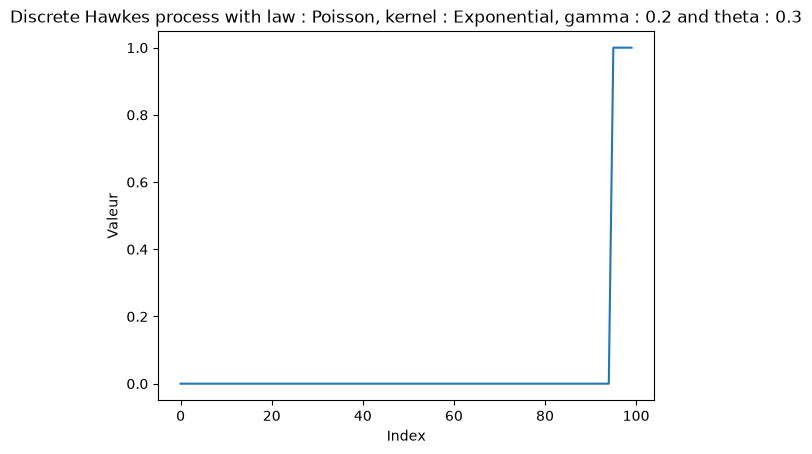

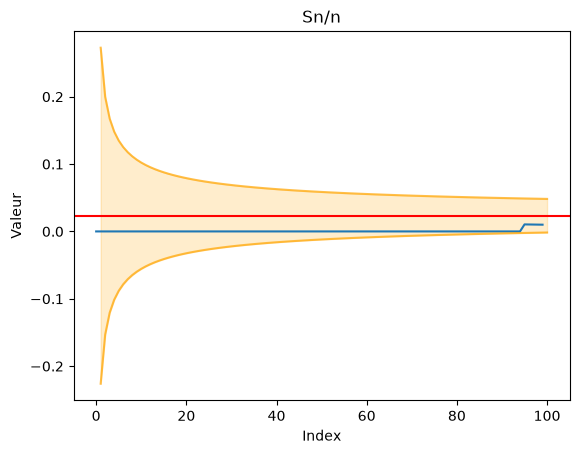

In [3]:
DHP("Exponential", 0.2, 0.3, "Poisson", 100, 0.01)

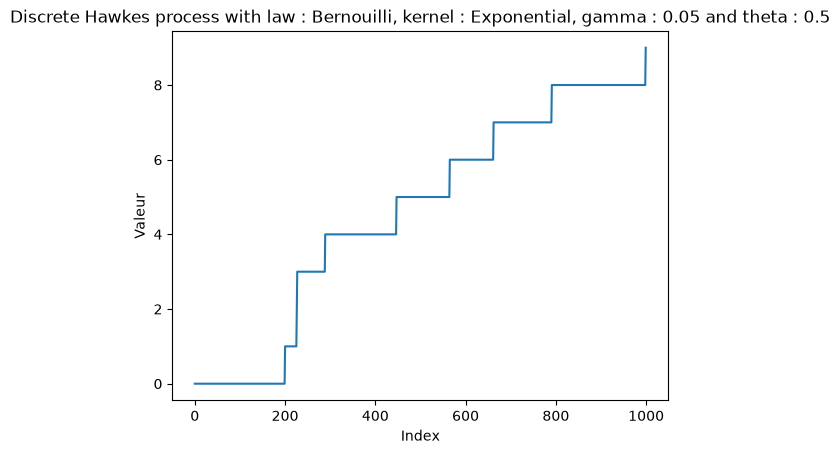

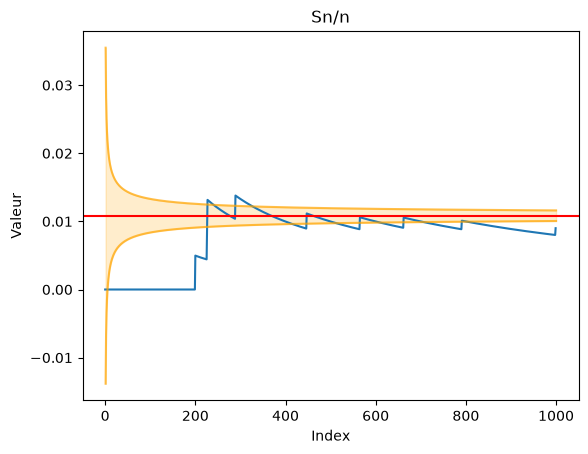

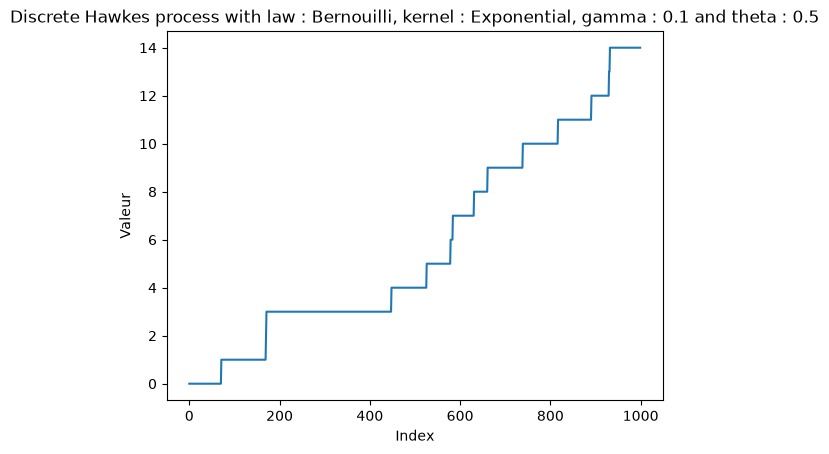

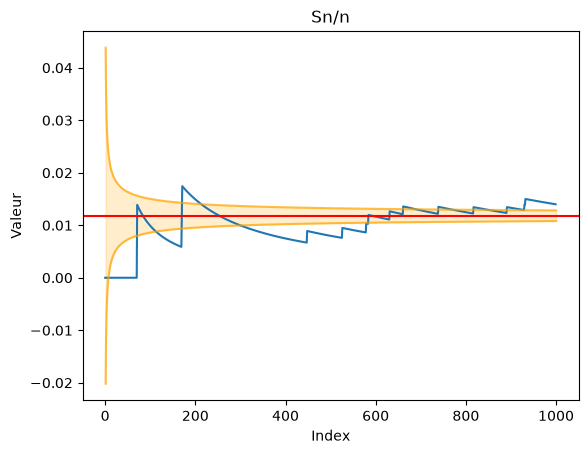

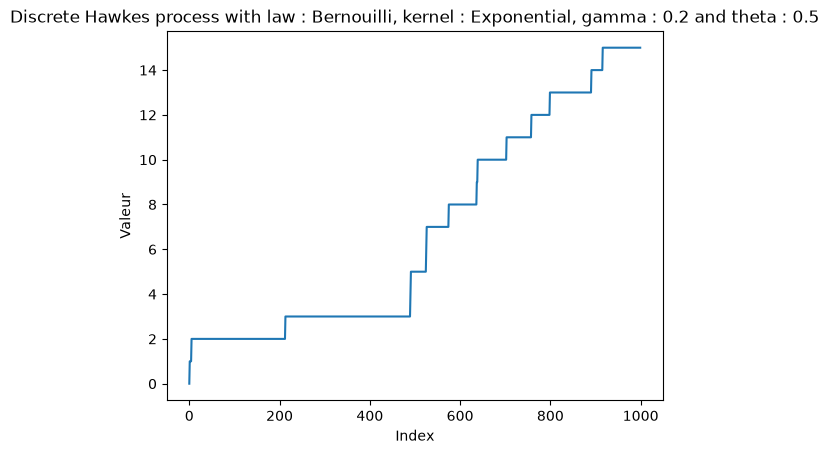

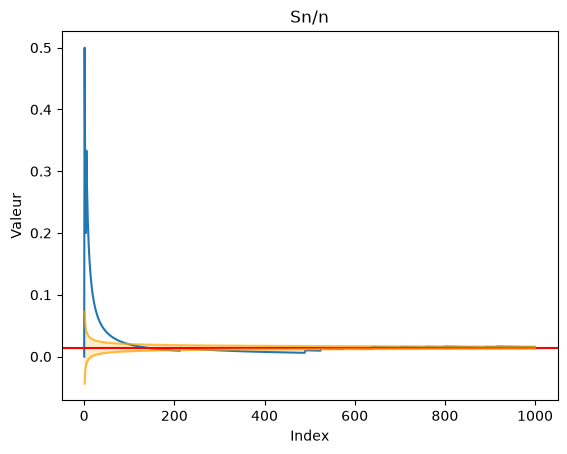

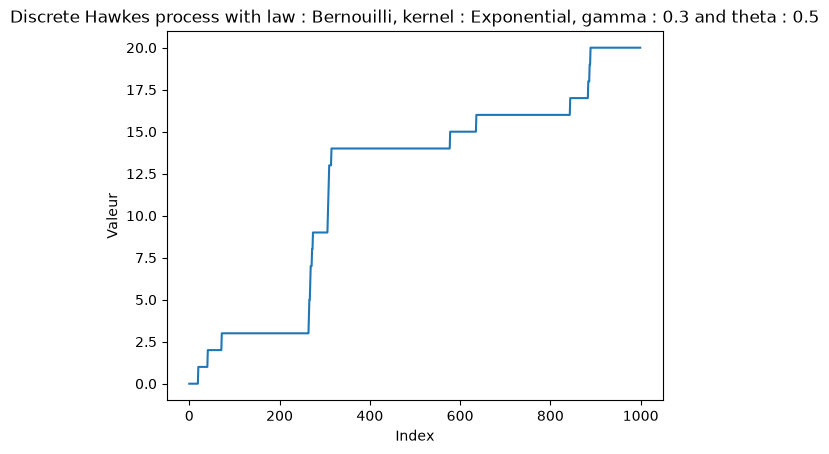

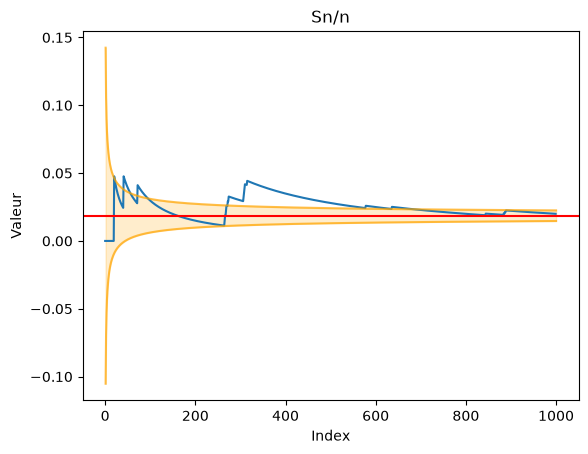

In [4]:
DHP("Exponential", 0.05, 0.5, "Bernouilli", 1000, 0.01)
DHP("Exponential", 0.10, 0.5, "Bernouilli", 1000, 0.01)
DHP("Exponential", 0.20, 0.5, "Bernouilli", 1000, 0.01)
DHP("Exponential", 0.30, 0.5, "Bernouilli", 1000, 0.01)


In [ ]:
#Let's try to code a continuous Hawkes Process
# First let's try to just inverse the distribution function
#Then we will use the Thinning d'Ogatta


#We can define it so easily and recursively just because we have an exponential kernel, which allows to just multiply each time
#For calculation, I'll add a note on how we came to such an easy loop !


def CHP(mu,beta,gamma,T_max):

    if gamma/beta>=1:
        raise ValueError("Attention, il est nécessaire d'avoir : γ/β < 1 afin d'assurer la condition sur la fonction d'excitation")

    #alpha 0 : intensité de fond (baseline)
    #gamma : amplitude du noyau d'excitation
    #beta : taux de décroissance

    T=0
    phi=0

    N=[]

    while True:
        u=np.random.uniform(0,1)
        F = lambda delta: 1 -(np.exp(-mu*delta - phi*(1-np.exp(-beta*delta))/beta)) #Fonction de répartition de Δn+1 appliqué en δ (on part de la fonction de survie)

        b = -np.log(1 - u) / mu + 1e-8   # borne haute garantie (car S(b) >= 1-e^{-mu*b} = u) : résultat analytique (see the note) 
        #On utilise cette borne haute pour être sûr que S(b)>0 et donc que l'algo brentq (qui nécessite au moins une annulation sur l'intervalle fonctionne)

        G_delta = brentq(lambda x: F(x) - u, 0, b) #G_delta est une simulation de la variable aléatoire Δn+1 

        T=T+ G_delta #Tn+1 = Tn + Δn+1   (ici G_delta car on utilise une simulation)
        if T > T_max:
            break #Permet de sortir de la boucle dès que le T calculé dépasse le T_max fixé

        phi=phi*np.exp(-beta*G_delta) + gamma #Φn+1 = Φn * exp(-β * Δn+1) + γ

        N.append(T) #N est totalement encodé par (T1,...,Tn)


    N = np.array(N)
    
    return N



In [ ]:
def CHP_plot(mu,beta,gamma,T_max):
    N=CHP(mu,beta,gamma,T_max)
    plt.step(np.concatenate([[0], N]),np.arange(len(N) + 1),where='post')
    plt.xlabel('t')
    plt.ylabel('N(t)')
    plt.title('Processus de Hawkes continu')
    plt.grid(True, alpha=0.3)
    plt.show()

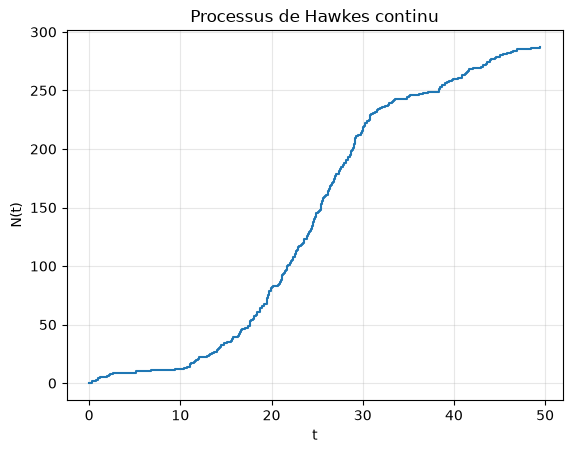

In [ ]:
mu = 1.0    # intensité de fond
gamma  = 0.8    # amplitude du noyau
beta   = 1.0    # taux de décroissance
T_max  = 50.0   # horizon

CHP_plot(mu,beta,gamma,T_max)

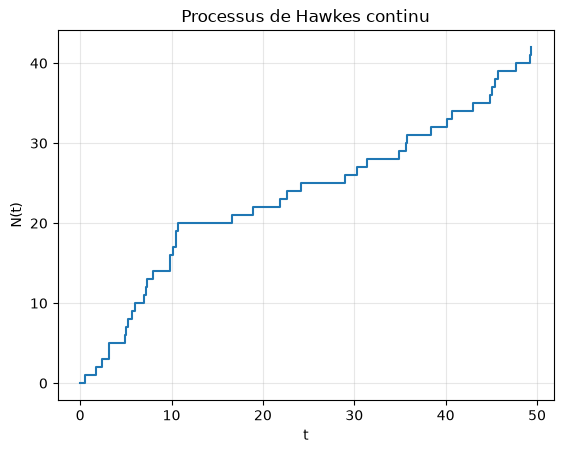

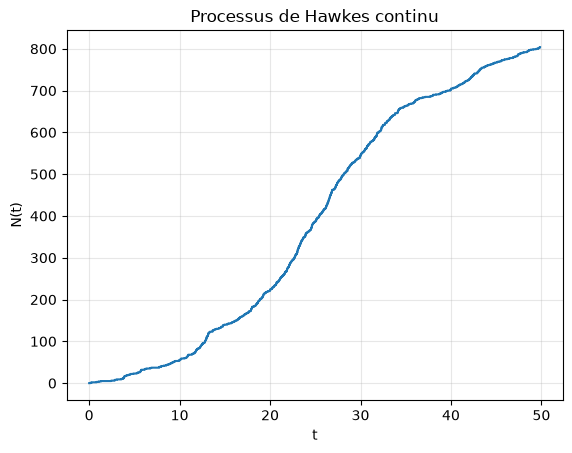

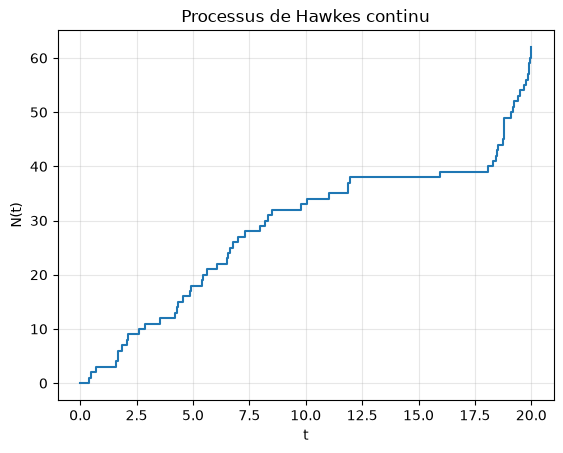

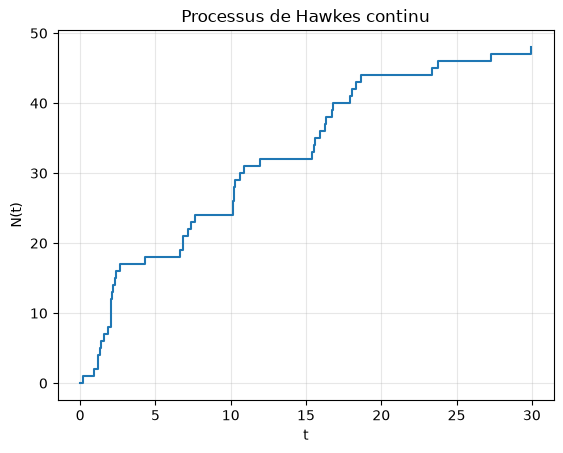

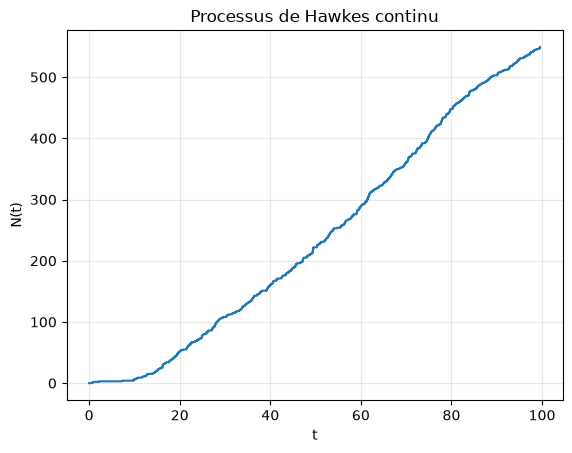

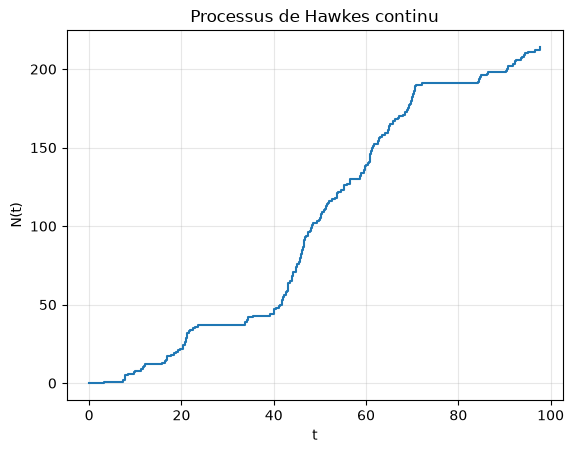

In [ ]:
# mu (fond)         : plancher de lambda* et taux des evts spontanes.
#                         plus grand -> moins de silences, pente de base de N(t) plus forte.
# gamma  (amplitude)    : hauteur du saut de lambda* a chaque evt.
#                         plus grand -> clustering plus intense ; vers 0 -> Poisson homogene.
# beta   (decroissance) : vitesse de retour vers mu, memoire ~ 1/beta.
#                         grand -> rafales compactes ; petit -> clusters etales.
# gamma/beta (branching) : regime global. vers 0 -> quasi-Poisson ;
#                          vers 1 -> cascades massives ; >= 1 -> explosion.
#                          intensite moyenne = mu / (1 - gamma/beta).


CHP_plot(mu=0.7, beta=5, gamma=1, T_max=50)     

# 2. Clustering fort mais stable
CHP_plot(mu=1.0, beta=1.0, gamma=0.9, T_max=50)

# 3. Quasi-critique : grosses cascades (baisse T_max pour ne pas exploser le compte)
CHP_plot(mu=0.5, beta=1.0, gamma=0.95, T_max=20)

# 4. Mémoire courte : rafales très serrées puis retour rapide au fond
CHP_plot(mu=1.0, beta=5.0, gamma=4.0, T_max=30)

# 5. Mémoire longue : excitation qui traîne, clusters étalés
CHP_plot(mu=1.0, beta=0.3, gamma=0.24, T_max=100)

# 6. Fond faible, très auto-excité : longs silences puis bouffées
CHP_plot(mu=0.2, beta=1.0, gamma=0.85, T_max=100)

In [9]:
# On va essayer d'établir 2 choses :
# Des intervalles de confiances qui dépendent de v (la proportion de l'intervalle [0,T] que l'on observe)   
# Un intervalle de confiance qui ne dépend pas de v, donc quelque soit la proportion de l'intervalle [0,T], on devrait se situer dedans

In [ ]:
# Intervalles de confiances qui dépendent de v
#De nouveau, ici on propose d'implémenter directement les résultats analytiques, voir la note.

def CHP_IC(v,mu,beta,gamma,T_max):
    
    mean=(v*mu)/(1-gamma/beta)

    sigma=np.sqrt(v*mu/(T_max*(1-gamma/beta)**3))

    return mean,sigma

In [ ]:
def CHP_IC_plot(mu,beta,gamma,T_max):
    v=np.linspace(0,1,100)

    mean_v=CHP_IC(v,mu,beta,gamma,T_max)[0]
    sigma_v=CHP_IC(v,mu,beta,gamma,T_max)[1]


    lower=mean_v - 1.96 * sigma_v
    upper=mean_v + 1.96 * sigma_v
    

    # Pour la boucle : ATTENTION, ça ne veut pas dire que 95% seront entièrement dans l'intervalle de confiance
    # Notre intervalle de confiance fonctionne à v fixé, ça serait plutôt donc :
    # à v fixé, 95% des 100 points (évaluation de la trajectoire en v) se situe dans l'intervalle de confiance

    # Pour pouvoir déduire que 95% des trajectoires sont censées être situées dans notre intervalle, il faudrait qu'on ai un intervalle indépendant de v
    # Ce qui est la prochaine étape
    
    for k in range(1,100): #Pour afficher une multitude de simulations de trajectoires (indépendantes)
        N=CHP(mu,beta,gamma,T_max)

        seuil=T_max*v
        N_T_v=np.searchsorted(N, seuil, side='right')
    
        N_div=N_T_v/T_max # = N(Tv)/T : c'est pour celui-ci qu'on veut faire un intervalle de confiance
        plt.plot(v,N_div, alpha=0.5)

    plt.title("N(Tv)/T")
    plt.plot(v, mean_v, color="red")
    plt.fill_between(
    v,
    lower,
    upper,
    color="orange",
    alpha=0.2,
    label="95% CI")
    plt.legend()
    plt.show()
    


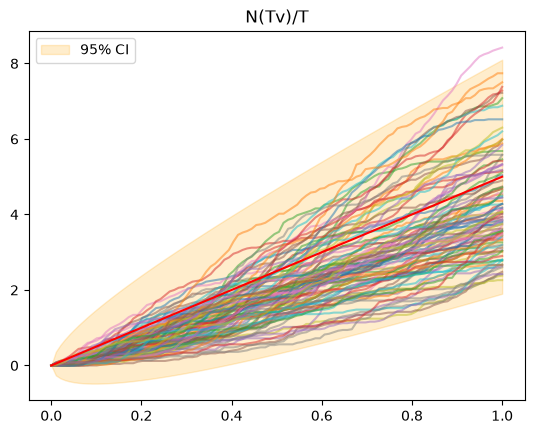

In [ ]:
CHP_IC_plot(mu,beta,gamma,T_max)

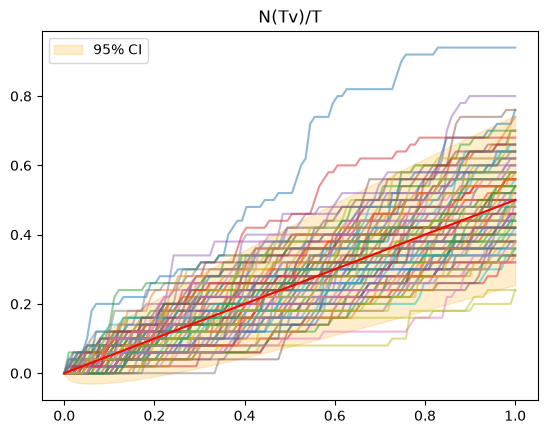

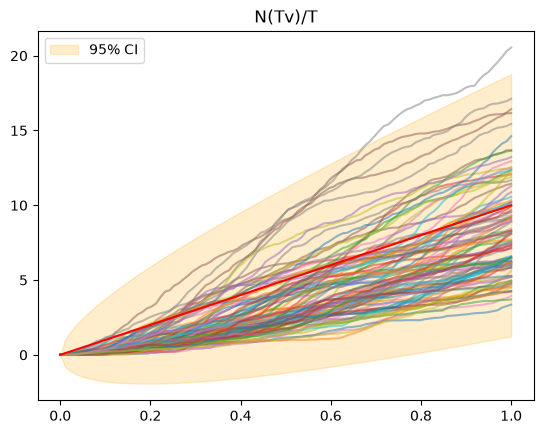

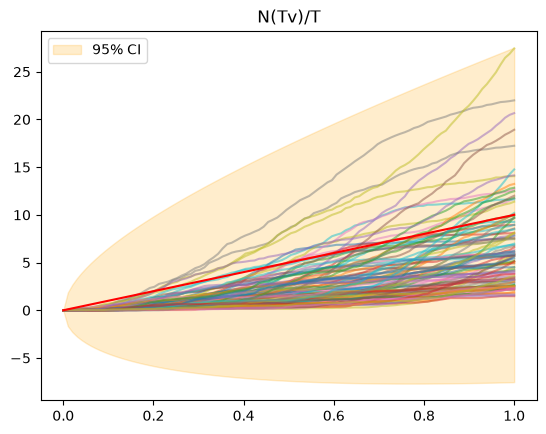

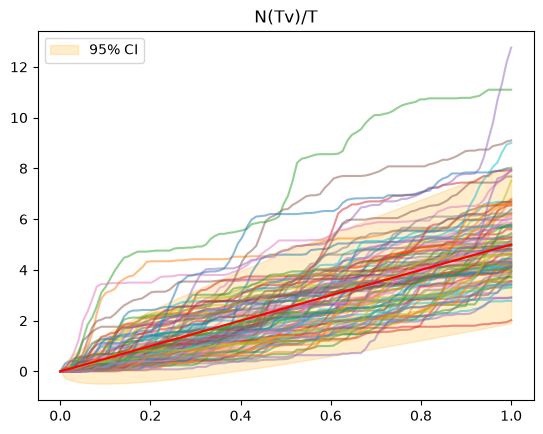

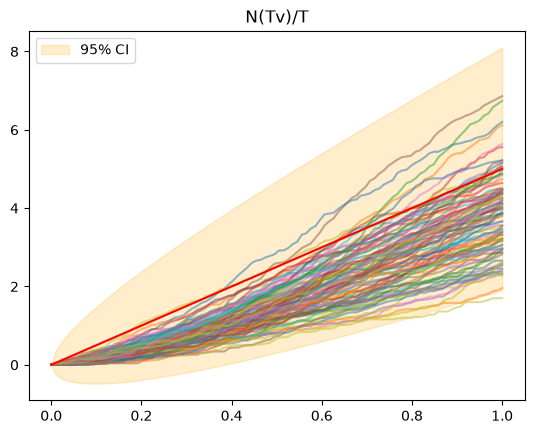

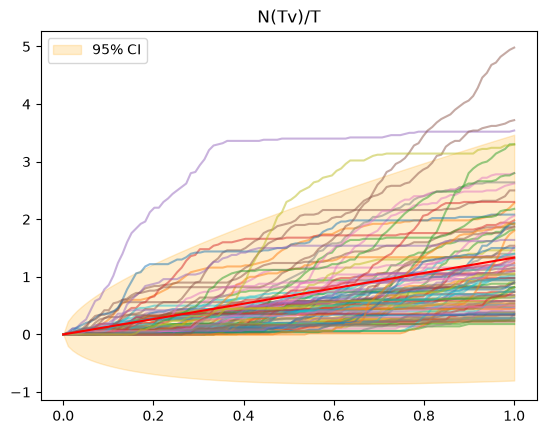

In [ ]:
#Quelques plots pour voir comment notre intervalle de confiance se comporte

CHP_IC_plot(mu=0.4, beta=5, gamma=1, T_max=50)     

# 2. Clustering fort mais stable
CHP_IC_plot(mu=1.0, beta=1.0, gamma=0.9, T_max=50)

# 3. Quasi-critique : grosses cascades (baisse T_max pour ne pas exploser le compte)
CHP_IC_plot(mu=0.5, beta=1.0, gamma=0.95, T_max=50)

# 4. Mémoire courte : rafales très serrées puis retour rapide au fond
CHP_IC_plot(mu=1.0, beta=5.0, gamma=4.0, T_max=50)

# 5. Mémoire longue : excitation qui traîne, clusters étalés
CHP_IC_plot(mu=1.0, beta=0.3, gamma=0.24, T_max=50)

# 6. Fond faible, très auto-excité : longs silences puis bouffées
CHP_IC_plot(mu=0.2, beta=1.0, gamma=0.85, T_max=50)

In [ ]:
time_stamp=CHP(mu=1.0, beta=0.3, gamma=0.24, T_max=10000)

In [ ]:
#The complexity should be O(len(time_stamp)) thanks to recursion

def neg_log_likelihood(theta,time_stamp):

    mu, R, beta = theta #Where R is the branchement ratio (which should be 0<.<1)
    #We use the branchement ratio, because it allows to use numerical methods more robusts to constraints

    gamma = R * beta #we recalculate gamma

    k=len(time_stamp)
    A = np.zeros(k)

    first_sum=np.log(mu+gamma*A[0])

    # First sum
    for i in range(1,k):
        A[i]=(1+A[i-1])*np.exp(-beta*(time_stamp[i]-time_stamp[i-1]))
        first_sum+=np.log(mu+gamma*A[i])
    
    # Second sum

    last_time=time_stamp[k-1]   

    second_sum = np.sum((gamma / beta) * (np.exp(-beta * (last_time - time_stamp)) - 1)) #time_stamp is a vector, so everything inside np.sum is a vector


    return -(first_sum - mu*last_time + second_sum)

In [ ]:
theta_init = np.array([0.5, 0.5, 0.3]) 


bounds = ((1e-5, None), (1e-5, 0.999), (1e-5, None))


resultat = minimize(
    fun=neg_log_likelihood,
    x0=theta_init,
    args=(time_stamp,),
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 2000, 'ftol': 1e-9}
)

print("\n--- RÉSULTATS DE L'ESTIMATION ---")
print(f"mu (baseline intensity) estimé      : {resultat.x[0]:.4f}")
print(f" Branchement Ratio (R) estimé   : {resultat.x[1]:.4f}")
print(f"Beta estimé        : {resultat.x[2]:.4f}")
print(f"-> Gamma déduit    : {(resultat.x[1] * resultat.x[2]):.4f}")
print(f"Succès             : {resultat.success}")


--- RÉSULTATS DE L'ESTIMATION ---
Alpha0 (baseline intensity) estimé      : 0.9678
 Branchement Ratio (R) estimé   : 0.8050
Beta estimé        : 0.2948
-> Gamma déduit    : 0.2373
Succès             : True


In [ ]:
def hawkes_residuals(theta, time_stamp):
    mu, R, beta = theta
    gamma = R * beta
    k = len(time_stamp)
    
    u = np.zeros(k - 1)
    A = np.zeros(k)
    
    #we apply the change theorem
    #We recursively calculate residuals : proof on paper
    for i in range(1, k):
        delta_t = time_stamp[i] - time_stamp[i-1]
        
        u[i-1] = mu * delta_t + (gamma / beta) * (1 - np.exp(-beta * delta_t)) * (1 + A[i-1])
        
        #Update
        A[i] = (1 + A[i-1]) * np.exp(-beta * delta_t)
        
    return u

In [18]:
theta_estime = [1.0055, 0.7997, 0.2981] 

# residuals estimated
u = hawkes_residuals(theta_estime, time_stamp)

print("--- Goodness of fit ---")

# TEST 1 : Kolmogorov-Smirnov (Marginal distribution Exp(1))
# H0 : data follows an Exp(1) distribution
ks_stat, ks_pval = kstest(u, 'expon')
print(f"KS Test       -> Stat: {ks_stat:.4f} | p-value: {ks_pval:.4f}")

# TEST 2 : Ljung-Box (Linear AC until the 20th lag)
# H0 : residuals are independant (no autocorrelation)
lb_result = acorr_ljungbox(u, lags=[20], return_df=True)
lb_pval = lb_result['lb_pvalue'].iloc[0]
print(f"Ljung-Box     -> Stat: {lb_result['lb_stat'].iloc[0]:.4f} | p-value: {lb_pval:.4f}")

--- Goodness of fit ---
KS Test       -> Stat: 0.0033 | p-value: 0.6592


Ljung-Box     -> Stat: 11.8370 | p-value: 0.9216


In [ ]:
#Test of excess of dispersion
#H0 : the variance of residuals is 1
def engle_russell_ed_test(u):

    N = len(u)
    
    #calculation of empirical dispersion (ddof = degrees of liberty = 1 to be unbiased)
    sigma2_hat = np.var(u, ddof=1)
    
    #We calculate our test statistic (that follows N(0,1) when N-> +inf)
    Z_stat = np.sqrt(N) * (sigma2_hat - 1) / np.sqrt(8)
    
    # bilateral p_value
    p_value = 2 * (1 - norm.cdf(np.abs(Z_stat)))
    
    return sigma2_hat, Z_stat, p_value



sigma2_empirique, ed_stat, ed_pval = engle_russell_ed_test(u)

print(f"empirical variance of résidus : {sigma2_empirique:.4f}")
print(f"Engle-Russell ED Test -> Stat Z: {ed_stat:.4f} | p-value: {ed_pval:.4f}")

empirical variance of résidus : 1.0099
Engle-Russell ED Test -> Stat Z: 0.7822 | p-value: 0.4341


#implémenter le test de lewis
add taht we can generate hawkes process by thinning

In [ ]:
count_ks = 0
count_lb = 0
count_er = 0
count_joint = 0

# Let's try to implement the pass_rate idea of the article
numerous_timestamps = [CHP(mu=1.0, beta=0.3, gamma=0.24, T_max=10000) for _ in range(10)]

taille = len(numerous_timestamps)
theta_init = np.array([0.5, 0.5, 0.3]) 
bounds = ((1e-5, None), (1e-5, 0.999), (1e-5, None))

for k in range(taille):
    current_timestamps = numerous_timestamps[k]

    resultat = minimize(
        fun=neg_log_likelihood, 
        x0=theta_init,
        args=(current_timestamps,), 
        method='L-BFGS-B',
        bounds=bounds,
        options={'maxiter': 2000, 'ftol': 1e-9}
    )

    theta_estimate = resultat.x
    
    u = hawkes_residuals(theta_estimate, current_timestamps)

    ks_stat, ks_pval = kstest(u, 'expon')

    lb_result = acorr_ljungbox(u, lags=[20], return_df=True)
    lb_pval = lb_result['lb_pvalue'].iloc[0]

    _, _, er_pval = engle_russell_ed_test(u)


    if ks_pval > 0.05:
        count_ks += 1

    if lb_pval > 0.05:
        count_lb += 1

    if er_pval > 0.05:
        count_er += 1

    if ks_pval > 0.05 and lb_pval > 0.05 and er_pval > 0.05:
        count_joint += 1

print("\n--- RÉSULTATS DES PASS RATES (sur 50 simulations) ---")
print(f"Pass Rate KS : {(count_ks / taille) * 100:.2f}%")
print(f"Pass Rate LB : {(count_lb / taille) * 100:.2f}%")
print(f"Pass Rate ED : {(count_er / taille) * 100:.2f}%")
print(f"Pass Rate Joint (KS ∩ LB ∩ ED) : {(count_joint / taille) * 100:.2f}%")


--- RÉSULTATS DES PASS RATES (sur 50 simulations) ---
Pass Rate KS : 100.00%
Pass Rate LB : 100.00%
Pass Rate ED : 100.00%
Pass Rate Joint (KS ∩ LB ∩ ED) : 100.00%


In [ ]:
# Hawkes bivariate (dim 0 = buy, dim 1 = sell) ---
baseline = np.array([0.3, 0.2])            # mu : [mu_buy, mu_sell]

adjacency = np.array([[0.2, 0.1],          # gamma : row = aim, column = source
                      [0.3, 0.15]])        # gamma[0,1] = impact of sell on buy

decays = np.array([[1.0, 1.0],             # beta : one per pair (aim, source)
                   [1.0, 1.0]])

# --- Simulateur ---
sim = SimuHawkesExpKernels(
    baseline=baseline,
    adjacency=adjacency,
    decays=decays,
    end_time=5000.0,
    seed=42,
    verbose=False,
)
sim.simulate()

t_buy, t_sell = sim.timestamps[0], sim.timestamps[1]

df_sim = pd.concat([
    pd.DataFrame({"time_stamp": t_buy,  "side": 1}),
    pd.DataFrame({"time_stamp": t_sell, "side": 0}),
], ignore_index=True).sort_values("time_stamp").reset_index(drop=True)

In [50]:
df_sim.head()

,time_stamp,side
0,2.814264,0
1,4.674147,1
2,6.922458,1
3,7.731103,1
4,7.987523,1


In [ ]:
def neg_log_likelihood_bivariate(theta,df):

    mu1, mu2, R11 , R21, R12, R22 , beta1, beta2 = theta #We use branchment ratio for numerical optimisation

    
    # We deduce gamma using branchment ratio
    gamma11 = R11 * beta1
    gamma21 = R21 * beta1
    gamma12 = R12 * beta2
    gamma22 = R22 * beta2

    #time_stamp and order type
    time_stamp = df['time_stamp'].to_numpy()
    side = df['side'].to_numpy()

    k=len(time_stamp)
    
    S1 = np.zeros(k+1)
    S2 = np.zeros(k+1)

    N1=side.sum()
    N2=k-N1


    first_sum=np.log(np.where(side[0]==1, mu1, mu2))

    # First sum
    for i in range(1,k):
        S1[i]=(side[i-1] + S1[i-1])*np.exp(-beta1*(time_stamp[i]-time_stamp[i-1]))
        
        S2[i]=((1-side[i-1]) + S2[i-1])*np.exp(-beta2*(time_stamp[i]-time_stamp[i-1]))

        if side[i]==1: 
            first_sum+=np.log( mu1 + gamma11*S1[i] + gamma12*S2[i])
        else:
            first_sum+=np.log( mu2 + gamma21*S1[i] + gamma22*S2[i])



    # Second sum

    last_time=time_stamp[k-1] 

    S1[k] = side[k-1] + S1[k-1]
        
    S2[k] = (1-side[k-1]) + S2[k-1]

    Re1 = N1 - S1[k]
    Re2 = N2 - S2[k]  

    second_sum = (R11 + R21)*Re1 + (R12 + R22)*Re2


    return -(first_sum - (mu1+mu2)*last_time - second_sum)

In [51]:
theta_init = np.array([
    0.1,  # mu1
    0.1,  # mu2
    0.1,  # R11
    0.1,  # R21
    0.1,  # R12
    0.1,  # R22
    0.9,  # beta1
    0.9   # beta2
])

In [57]:
#Numerous constraints to respect :

def spectral_det(theta):
    return (1.0 - theta[2]) * (1.0 - theta[5]) - (theta[4] * theta[3]) - 1e-5

def trace_1(theta):
    return 1.0 - theta[2] - 1e-5

def trace_2(theta):
    return 1.0 - theta[5] - 1e-5


# Linear constraints
bounds = (
    (1e-5, None), # 0: mu1 > 0
    (1e-5, None), # 1: mu2 > 0
    (0, None),    # 2: R11 >= 0
    (0, None),    # 3: R21 >= 0
    (0, None),    # 4: R12 >= 0
    (0, None),    # 5: R22 >= 0
    (1e-5, None), # 6: beta1 > 0
    (1e-5, None)  # 7: beta2 > 0
)

# inequality constraints
contraintes_trust = [
    NonlinearConstraint(spectral_det, 1e-5, np.inf),
    NonlinearConstraint(trace_1, 1e-5, np.inf),
    NonlinearConstraint(trace_2, 1e-5, np.inf)
]

#
resultat = minimize(
    fun=neg_log_likelihood_bivariate, 
    x0=theta_init,
    args=(df_sim,), 
    method='trust-constr', # We try another algorithm : which is more robust to 
    bounds=bounds,
    constraints=contraintes_trust,
    options={'maxiter': 2000, 'xtol': 1e-8, 'gtol': 1e-8, 'disp': True}
)

print("\n--- Bivariate : Estimated results ---")
print(f"Succès de l'optimisation : {resultat.success}")
print(f"Statut                   : {resultat.message}")

print("\n[Baseline intensity - mu]")
print(f"mu1 (Dimension 1) : {resultat.x[0]:.6f}")
print(f"mu2 (Dimension 2) : {resultat.x[1]:.6f}")

print("\n[Branchement ratio matrix - R]")
print(f"R11 (Auto-excitation 1->1)   : {resultat.x[2]:.4f}")
print(f"R21 (Croisée 1->2)           : {resultat.x[3]:.4f}")
print(f"R12 (Croisée 2->1)           : {resultat.x[4]:.4f}")
print(f"R22 (Auto-excitation 2->2)   : {resultat.x[5]:.4f}")

print("\n[beta]")
print(f"beta1 (Chocs issus de 1) : {resultat.x[6]:.4f}")
print(f"beta2 (Chocs issus de 2) : {resultat.x[7]:.4f}")

print("\n[gamma]")
print(f"-> gamma11 : {(resultat.x[2] * resultat.x[6]):.4f}")
print(f"-> gamma21 : {(resultat.x[3] * resultat.x[6]):.4f}")
print(f"-> gamma12 : {(resultat.x[4] * resultat.x[7]):.4f}")
print(f"-> gamma22 : {(resultat.x[5] * resultat.x[7]):.4f}")

/opt/python/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:737: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(delta_x, delta_g)
/opt/python/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:385: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


`xtol` termination condition is satisfied.
Number of iterations: 212, function evaluations: 2232, CG iterations: 873, optimality: 1.85e-02, constraint violation: 0.00e+00, execution time: 3e+02 s.

--- Bivariate : Estimated results ---
Succès de l'optimisation : True
Statut                   : `xtol` termination condition is satisfied.

[Baseline intensity - mu]
mu1 (Dimension 1) : 0.302151
mu2 (Dimension 2) : 0.193820

[Branchement ratio matrix - R]
R11 (Auto-excitation 1->1)   : 0.1961
R21 (Croisée 1->2)           : 0.3050
R12 (Croisée 2->1)           : 0.0980
R22 (Auto-excitation 2->2)   : 0.1548

[beta]
beta1 (Chocs issus de 1) : 0.9538
beta2 (Chocs issus de 2) : 1.0364

[gamma]
-> gamma11 : 0.1871
-> gamma21 : 0.2909
-> gamma12 : 0.1016
-> gamma22 : 0.1604


In [ ]:
#Numerous constraints to respect :

def spectral_det(theta):
    return (1.0 - theta[2]) * (1.0 - theta[5]) - (theta[4] * theta[3]) - 1e-5

def trace_1(theta):
    return 1.0 - theta[2] - 1e-5

def trace_2(theta):
    return 1.0 - theta[5] - 1e-5


# Linear constraints
bounds = (
    (1e-5, None), # 0: mu1 > 0
    (1e-5, None), # 1: mu2 > 0
    (0, None),    # 2: R11 >= 0
    (0, None),    # 3: R21 >= 0
    (0, None),    # 4: R12 >= 0
    (0, None),    # 5: R22 >= 0
    (1e-5, None), # 6: beta1 > 0
    (1e-5, None)  # 7: beta2 > 0
)

# Inequalities constraints
contraintes = [
    {'type': 'ineq', 'fun': spectral_det},
    {'type': 'ineq', 'fun': trace_1},
    {'type': 'ineq', 'fun': trace_2}
]


resultat = minimize(
    fun=neg_log_likelihood_bivariate,
    x0=theta_init,
    args=(df_sim,),
    method='SLSQP',
    bounds=bounds,
    constraints=contraintes,
    options={'maxiter': 2000, 'ftol': 1e-9, 'disp': True}
)

print("\n--- Bivariate : Estimated results ---")
print(f"Succès de l'optimisation : {resultat.success}")
print(f"Statut                   : {resultat.message}")

print("\n[Baseline intensity - mu]")
print(f"mu1 (Dimension 1) : {resultat.x[0]:.6f}")
print(f"mu2 (Dimension 2) : {resultat.x[1]:.6f}")

print("\n[Branchement ratio matrix - R]")
print(f"R11 (Auto-excitation 1->1)   : {resultat.x[2]:.4f}")
print(f"R21 (Croisée 1->2)           : {resultat.x[3]:.4f}")
print(f"R12 (Croisée 2->1)           : {resultat.x[4]:.4f}")
print(f"R22 (Auto-excitation 2->2)   : {resultat.x[5]:.4f}")

print("\n[beta]")
print(f"beta1 (Chocs issus de 1) : {resultat.x[6]:.4f}")
print(f"beta2 (Chocs issus de 2) : {resultat.x[7]:.4f}")

print("\n[gamma]")
print(f"-> gamma11 : {(resultat.x[2] * resultat.x[6]):.4f}")
print(f"-> gamma21 : {(resultat.x[3] * resultat.x[6]):.4f}")
print(f"-> gamma12 : {(resultat.x[4] * resultat.x[7]):.4f}")
print(f"-> gamma22 : {(resultat.x[5] * resultat.x[7]):.4f}")

Optimization terminated successfully    (Exit mode 0)
            Current function value: 74527.9005313846
            Iterations: 59
            Function evaluations: 597
            Gradient evaluations: 58

--- Bivariate : Estimated results ---
Succès de l'optimisation : True
Statut                   : Optimization terminated successfully

[Baseline intensity - mu]
mu1 (Dimension 1) : 0.302438
mu2 (Dimension 2) : 0.202240

[Branchement ratio matrix - R]
R11 (Auto-excitation 1->1)   : 0.1954
R21 (Croisée 1->2)           : 0.2973
R12 (Croisée 2->1)           : 0.1084
R22 (Auto-excitation 2->2)   : 0.1534

[beta]
beta1 (Chocs issus de 1) : 1.0117
beta2 (Chocs issus de 2) : 0.9378

[gamma]
-> gamma11 : 0.1977
-> gamma21 : 0.3007
-> gamma12 : 0.1017
-> gamma22 : 0.1439


In [58]:
def hawkes_residuals_bivariate(theta, df):
    mu1, mu2, R11, R21, R12, R22, beta1, beta2 = theta
    time_stamp = df.iloc[:, 0].to_numpy()
    side = df.iloc[:, 1].to_numpy()
    k = len(time_stamp)
    
    S1 = np.zeros(k)
    S2 = np.zeros(k)
    N1 = np.zeros(k)
    N2 = np.zeros(k)
    
    Lambda1 = np.zeros(k)
    Lambda2 = np.zeros(k)
    
    # The compensator at the first event, only depends on passed time
    Lambda1[0] = mu1 * time_stamp[0]
    Lambda2[0] = mu2 * time_stamp[0]
    
    # Evaluation of the global compensator at each instant t_i
    for i in range(1, k):
        delta_t = time_stamp[i] - time_stamp[i-1]
        
        is_buy = side[i-1]
        is_sell = 1 - side[i-1]
        
        # update of cumulative counts N(t)
        N1[i] = N1[i-1] + is_buy
        N2[i] = N2[i-1] + is_sell
        
        # update of historical chocs S(t)
        S1[i] = (is_buy + S1[i-1]) * np.exp(-beta1 * delta_t)
        S2[i] = (is_sell + S2[i-1]) * np.exp(-beta2 * delta_t)
        
        # We use the exact (analytical) primitive
        Lambda1[i] = mu1 * time_stamp[i] + R11 * (N1[i] - S1[i]) + R12 * (N2[i] - S2[i])
        Lambda2[i] = mu2 * time_stamp[i] + R21 * (N1[i] - S1[i]) + R22 * (N2[i] - S2[i])
        
    # We use change time theorem
    # We separate according to the side
    tau_1 = Lambda1[side == 1]
    tau_2 = Lambda2[side == 0]
    
    # the residuals u_i are the time between events in the new reper
    u1 = np.diff(tau_1)
    u2 = np.diff(tau_2)
    
    return u1, u2

In [59]:
theta_estimate = [resultat.x[i] for i in range(8)]

In [60]:
# residuals estimated
u1,u2 = hawkes_residuals_bivariate(theta_estimate,df_sim)

residuals=[u1,u2]
print("--- Goodness of fit ---")

#Test of excess of dispersion
#H0 : the variance of residuals is 1
def engle_russell_ed_test(u):

    N = len(u)
    
    #calculation of empirical dispersion (ddof = degrees of liberty = 1 to be unbiased)
    sigma2_hat = np.var(u, ddof=1)
    
    #We calculate our test statistic (that follows N(0,1) when N-> +inf)
    Z_stat = np.sqrt(N) * (sigma2_hat - 1) / np.sqrt(8)
    
    # bilateral p_value
    p_value = 2 * (1 - norm.cdf(np.abs(Z_stat)))
    
    return sigma2_hat, Z_stat, p_value


for u in residuals:
    # TEST 1 : Kolmogorov-Smirnov (Marginal distribution Exp(1))
    # H0 : data follows an Exp(1) distribution
    ks_stat, ks_pval = kstest(u, 'expon')
    print(f"KS Test       -> Stat: {ks_stat:.4f} | p-value: {ks_pval:.4f}")

    # TEST 2 : Ljung-Box (Linear AC until the 20th lag)
    # H0 : residuals are independant (no autocorrelation)
    lb_result = acorr_ljungbox(u, lags=[20], return_df=True)
    lb_pval = lb_result['lb_pvalue'].iloc[0]
    print(f"Ljung-Box     -> Stat: {lb_result['lb_stat'].iloc[0]:.4f} | p-value: {lb_pval:.4f}")



    sigma2_empirique, ed_stat, ed_pval = engle_russell_ed_test(u)

    print(f"empirical variance of résidus : {sigma2_empirique:.4f}")
    print(f"Engle-Russell ED Test -> Stat Z: {ed_stat:.4f} | p-value: {ed_pval:.4f}")

--- Goodness of fit ---
KS Test       -> Stat: 0.0035 | p-value: 0.9534
Ljung-Box     -> Stat: 25.5548 | p-value: 0.1810
empirical variance of résidus : 0.9820
Engle-Russell ED Test -> Stat Z: -0.9227 | p-value: 0.3562
KS Test       -> Stat: 0.0036 | p-value: 0.9658
Ljung-Box     -> Stat: 22.4711 | p-value: 0.3155
empirical variance of résidus : 0.9913
Engle-Russell ED Test -> Stat Z: -0.4269 | p-value: 0.6694


In [61]:
# All our counters
count_ks_1, count_ks_2 = 0, 0
count_lb_1, count_lb_2 = 0, 0
count_er_1, count_er_2 = 0, 0
count_joint_1, count_joint_2 = 0, 0
count_global_joint = 0

taille = 10 # Number of simulations we want
numerous_dfs = []

# Generation of bivariate simulations (using tick)
for i in range(taille):
    sim = SimuHawkesExpKernels(
    baseline=baseline,
    adjacency=adjacency,
    decays=decays,
    end_time=5000.0,
    seed=i,
    verbose=False,
    )

    sim.simulate() 
    t_buy, t_sell = sim.timestamps[0], sim.timestamps[1]

    df_sim = pd.concat([
        pd.DataFrame({"time_stamp": t_buy,  "side": 1}),
        pd.DataFrame({"time_stamp": t_sell, "side": 0}),
    ], ignore_index=True).sort_values("time_stamp").reset_index(drop=True)
    
    numerous_dfs.append(df_sim)


# Evaluation Loop
for k in range(taille):
    current_df = numerous_dfs[k]

    
    # Optimization SLSQP
    resultat = minimize(
    fun=neg_log_likelihood_bivariate, 
    x0=theta_init,
    args=(df_sim,), 
    method='trust-constr', # We try another algorithm : which is more robust to 
    bounds=bounds,
    constraints=contraintes_trust,
    options={'maxiter': 2000, 'xtol': 1e-8, 'gtol': 1e-8, 'disp': True}
    )
    
    # Two vectors of residuals
    u1, u2 = hawkes_residuals_bivariate(resultat.x, current_df)

    
    # Test on dim=1 (Buy)
    _, ks_pval_1 = kstest(u1, 'expon')
    lb_pval_1 = acorr_ljungbox(u1, lags=[20], return_df=True)['lb_pvalue'].iloc[0]
    _, _, er_pval_1 = engle_russell_ed_test(u1)

    pass_ks_1 = ks_pval_1 > 0.05
    pass_lb_1 = lb_pval_1 > 0.05
    pass_er_1 = er_pval_1 > 0.05

    if pass_ks_1: count_ks_1 += 1
    if pass_lb_1: count_lb_1 += 1
    if pass_er_1: count_er_1 += 1
    if pass_ks_1 and pass_lb_1 and pass_er_1: count_joint_1 += 1

    # Test on dim=2 (Sell)
    _, ks_pval_2 = kstest(u2, 'expon')
    lb_pval_2 = acorr_ljungbox(u2, lags=[20], return_df=True)['lb_pvalue'].iloc[0]
    _, _, er_pval_2 = engle_russell_ed_test(u2)

    pass_ks_2 = ks_pval_2 > 0.05
    pass_lb_2 = lb_pval_2 > 0.05
    pass_er_2 = er_pval_2 > 0.05

    if pass_ks_2: count_ks_2 += 1
    if pass_lb_2: count_lb_2 += 1
    if pass_er_2: count_er_2 += 1
    if pass_ks_2 and pass_lb_2 and pass_er_2: count_joint_2 += 1

    # Strict Global Test (everything needs to pass)
    if (pass_ks_1 and pass_lb_1 and pass_er_1) and (pass_ks_2 and pass_lb_2 and pass_er_2):
        count_global_joint += 1

# Every Pass_Rates
print(f"\n--- PASS RATE RESULTS (out of {taille} simulations) ---")
print("\n[Dimension 1 - Buys]")
print(f"KS : {(count_ks_1 / taille) * 100:.2f}% | LB : {(count_lb_1 / taille) * 100:.2f}% | ED : {(count_er_1 / taille) * 100:.2f}%")
print(f"Joint 1 : {(count_joint_1 / taille) * 100:.2f}%")

print("\n[Dimension 2 - Sells]")
print(f"KS : {(count_ks_2 / taille) * 100:.2f}% | LB : {(count_lb_2 / taille) * 100:.2f}% | ED : {(count_er_2 / taille) * 100:.2f}%")
print(f"Joint 2 : {(count_joint_2 / taille) * 100:.2f}%")

print("\n[Global Bivariate Model]")
print(f"Strict Validation (Intersection of all 6 tests) : {(count_global_joint / taille) * 100:.2f}%")

/opt/python/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:737: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(delta_x, delta_g)
/opt/python/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:385: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


`xtol` termination condition is satisfied.
Number of iterations: 207, function evaluations: 2151, CG iterations: 877, optimality: 4.03e-04, constraint violation: 0.00e+00, execution time: 3.1e+01 s.
`xtol` termination condition is satisfied.
Number of iterations: 207, function evaluations: 2151, CG iterations: 877, optimality: 4.03e-04, constraint violation: 0.00e+00, execution time: 2.9e+01 s.
`xtol` termination condition is satisfied.
Number of iterations: 207, function evaluations: 2151, CG iterations: 877, optimality: 4.03e-04, constraint violation: 0.00e+00, execution time: 2.9e+01 s.
`xtol` termination condition is satisfied.
Number of iterations: 207, function evaluations: 2151, CG iterations: 877, optimality: 4.03e-04, constraint violation: 0.00e+00, execution time: 2.9e+01 s.
`xtol` termination condition is satisfied.
Number of iterations: 207, function evaluations: 2151, CG iterations: 877, optimality: 4.03e-04, constraint violation: 0.00e+00, execution time: 3e+01 s.
`xtol` 